# Segmentação Watershed — Separação de Objetos Sobrepostos

**Técnica:** Segmentação por Região (Watershed) — Visão Computacional  
**Bibliotecas:** OpenCV + scikit-image

## Intuição do algoritmo

Imagine a imagem como um mapa topográfico onde regiões claras são montanhas e regiões escuras são vales. Se 'inundarmos' o mapa, a água sobe a partir de cada vale (marker). Quando águas de vales diferentes se encontram, formam uma **linha de separação** — é assim que o watershed separa objetos colados.

## Pipeline

```
Imagem  →  CLAHE        (realça contraste)
        →  Otsu         (binariza)
        →  Morfologia   (limpa ruído)
        →  Distance T.  (mapa de distâncias)
        →  Threshold    (núcleos = markers)
        →  Watershed    (expande até as bordas)
```


## 1. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

## 2. Carregar a imagem das moedas

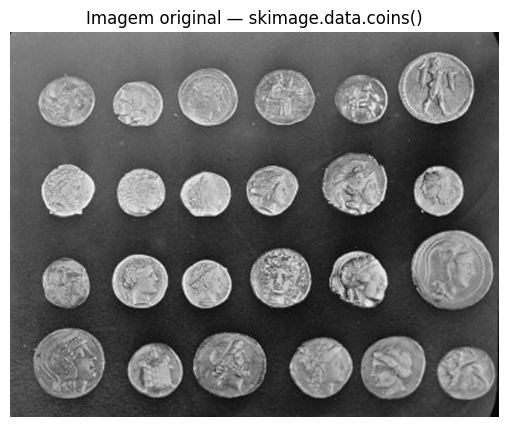

Shape: (454, 576, 3)


In [2]:
cinza = data.coins()
cinza = cv2.resize(cinza, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
bgr = cv2.cvtColor(cinza, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8, 5))
plt.imshow(cinza, cmap='gray')
plt.title('Imagem original — skimage.data.coins()')
plt.axis('off')
plt.show()
print('Shape:', bgr.shape)

## 3. Pré-processamento: CLAHE + blur + Otsu

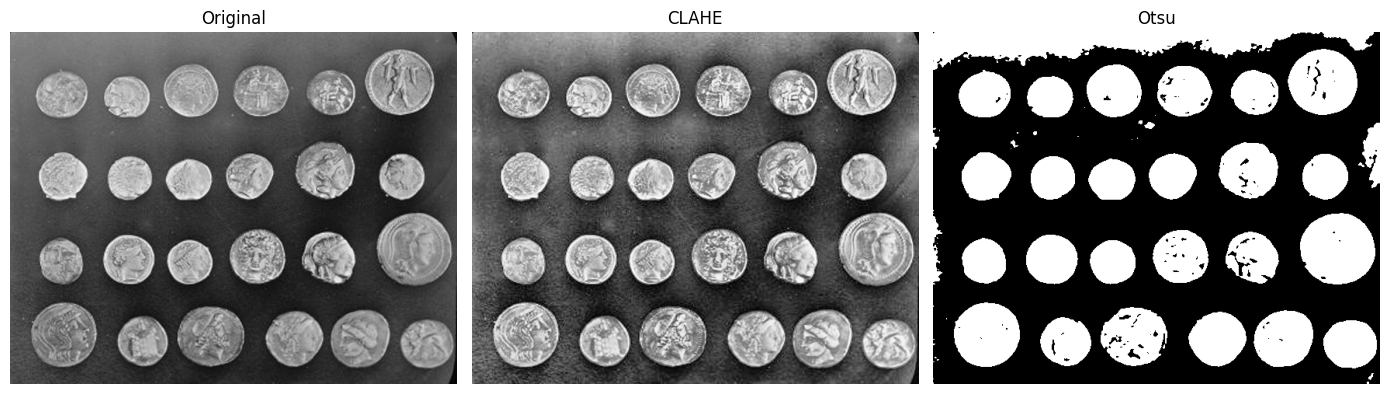

In [3]:
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
cinza_eq = clahe.apply(cinza)
cinza_blur = cv2.GaussianBlur(cinza_eq, (5, 5), 0)
_, binario = cv2.threshold(cinza_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, img, t in zip(axes, [cinza, cinza_eq, binario], ['Original', 'CLAHE', 'Otsu']):
    ax.imshow(img, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Morfologia + Distance Transform

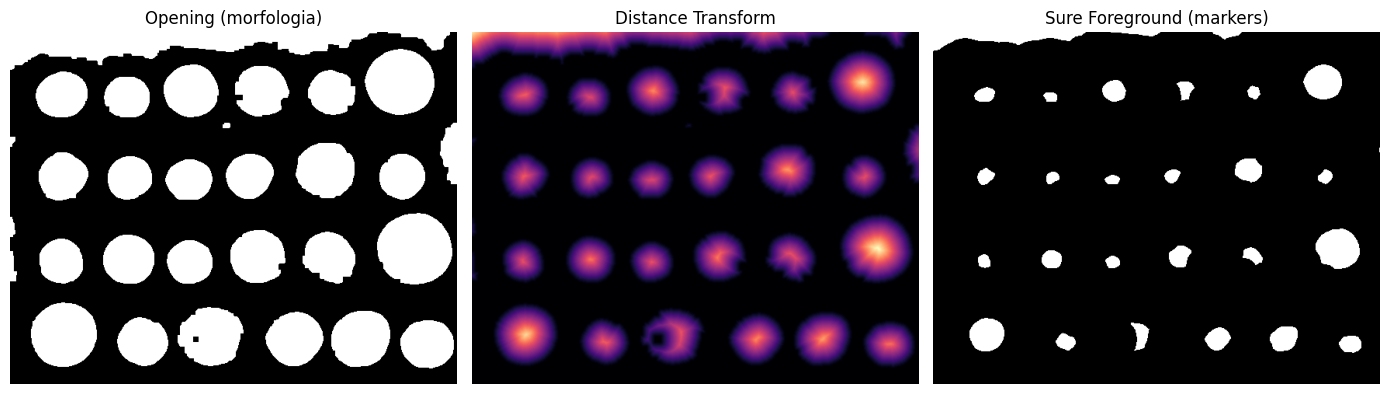

In [4]:
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binario, cv2.MORPH_OPEN, kernel, iterations=2)
opening = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=3)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.45 * dist.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)
desconhecido = cv2.subtract(sure_bg, sure_fg)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(opening, cmap='gray'); axes[0].set_title('Opening (morfologia)')
axes[1].imshow(dist, cmap='magma'); axes[1].set_title('Distance Transform')
axes[2].imshow(sure_fg, cmap='gray'); axes[2].set_title('Sure Foreground (markers)')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

## 5. Aplicar Watershed

28 objetos detectados


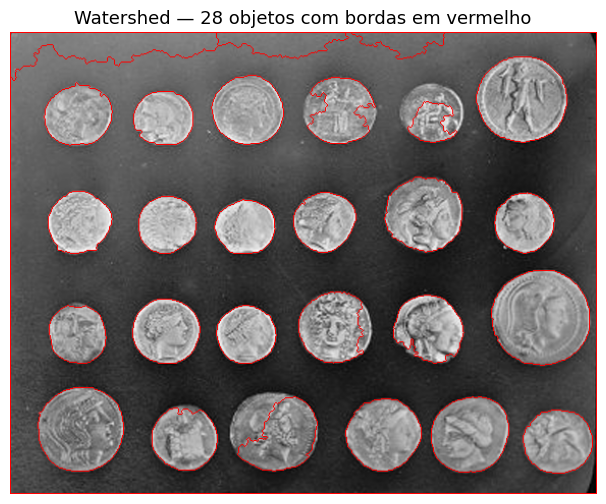

In [5]:
num_markers, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[desconhecido == 255] = 0
markers = cv2.watershed(bgr.copy(), markers)

resultado = bgr.copy()
resultado[markers == -1] = [0, 0, 255]

n_objetos = num_markers - 1
print(f'{n_objetos} objetos detectados')

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title(f'Watershed — {n_objetos} objetos com bordas em vermelho', fontsize=13)
plt.axis('off'); plt.show()

## 6. Visualização final colorida por segmento

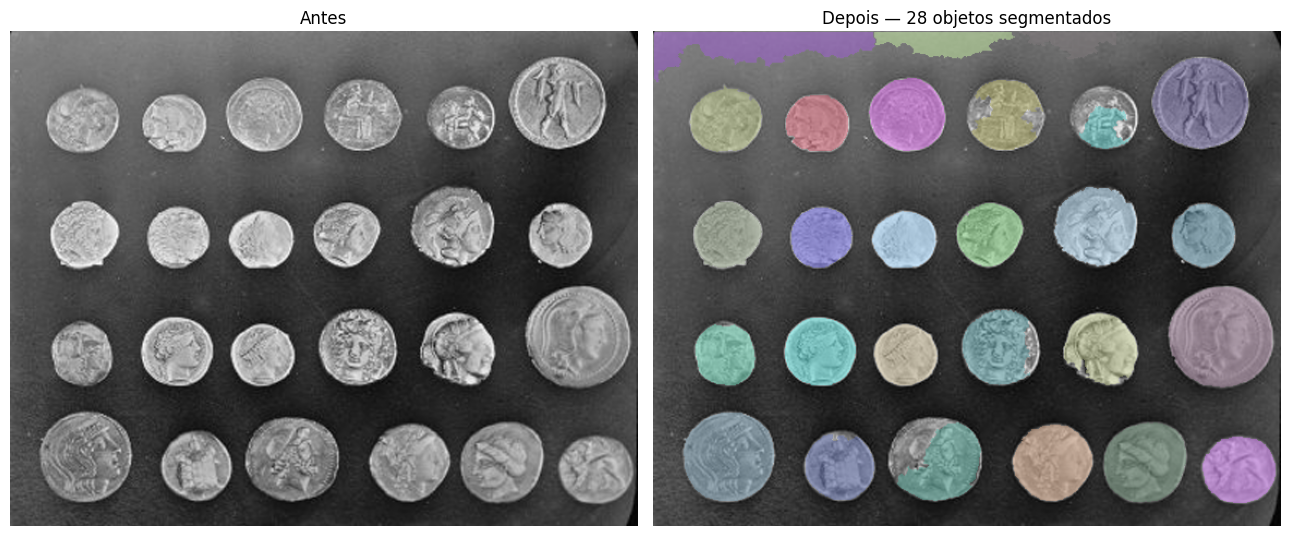

In [6]:
rng = np.random.default_rng(seed=42)
h, w = markers.shape
colorido = np.zeros((h, w, 3), dtype=np.uint8)
for label in np.unique(markers):
    if label <= 1: continue
    colorido[markers == label] = rng.integers(60, 255, size=3, dtype=np.uint8)

overlay = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
mask = colorido.sum(axis=2) > 0
overlay[mask] = (0.55 * overlay[mask] + 0.45 * colorido[mask]).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title('Antes'); axes[0].axis('off')
axes[1].imshow(overlay); axes[1].set_title(f'Depois — {n_objetos} objetos segmentados'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Conclusão

A pipeline detectou e separou as moedas — mesmo as que aparecem coladas — usando o algoritmo Watershed do OpenCV. Os passos críticos foram:

1. **CLAHE** para que moedas escuras (canto superior) sobrevivessem ao Otsu
2. **Distance Transform** para encontrar o 'centro' de cada moeda
3. **connectedComponents** para gerar markers únicos por região
4. **cv2.watershed** para expandir cada marker até encontrar bordas
